In [91]:
import pandas as pd 
import numpy as np  
import matplotlib as plt 
import seaborn as sns 
import warnings


In [92]:
df = pd.read_csv("EasyVisa.csv")
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [93]:
df.drop('case_id', inplace=True, axis=1)

In [94]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [95]:
from pymongo import auth_oidc_shared
from datetime import date
todays_date = date.today()
current_years = todays_date.year
current_years


2026

In [96]:
df['company_age']= current_years - df['yr_of_estab']

In [97]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [98]:
df.drop('yr_of_estab', axis=1, inplace=True )

In [99]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


In [100]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()



In [101]:
num_cols

['no_of_employees', 'prevailing_wage', 'company_age']

In [102]:

# Texto o Categóricas
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [103]:
cat_cols

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [104]:
X = df.drop('case_status', axis = 1)
y= df['case_status']

In [105]:
X

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,21
...,...,...,...,...,...,...,...,...,...,...
25475,Asia,Bachelor's,Y,Y,2601,South,77092.5700,Year,Y,18
25476,Asia,High School,Y,N,3274,Northeast,279174.7900,Year,Y,20
25477,Asia,Master's,Y,N,1121,South,146298.8500,Year,N,116
25478,Asia,Master's,Y,Y,1918,West,86154.7700,Year,Y,139


In [106]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

In [107]:
y = np.where(y=='Denied', 1,0)

In [108]:
y

array([1, 0, 1, ..., 0, 0, 0], shape=(25480,))

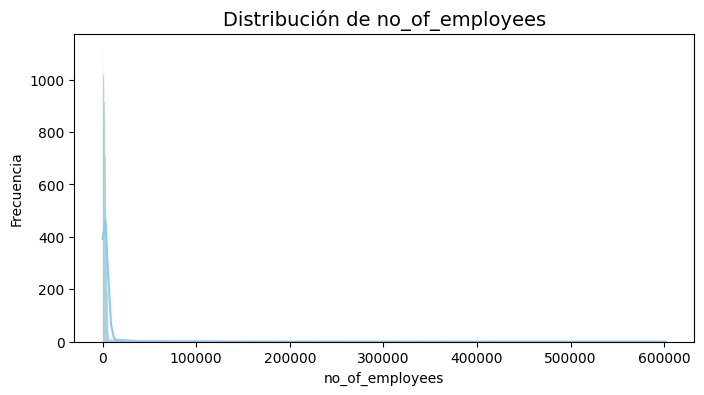

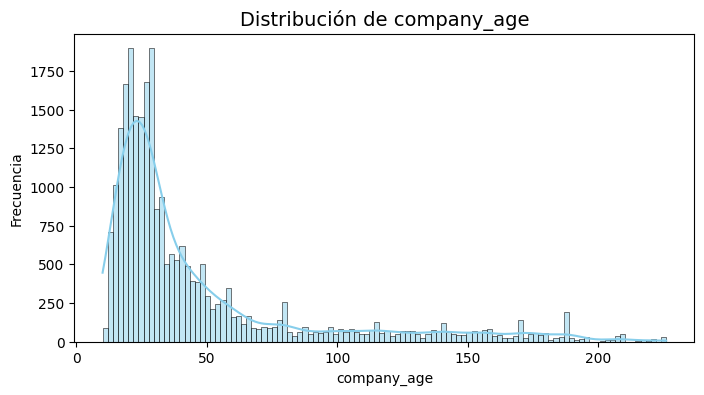

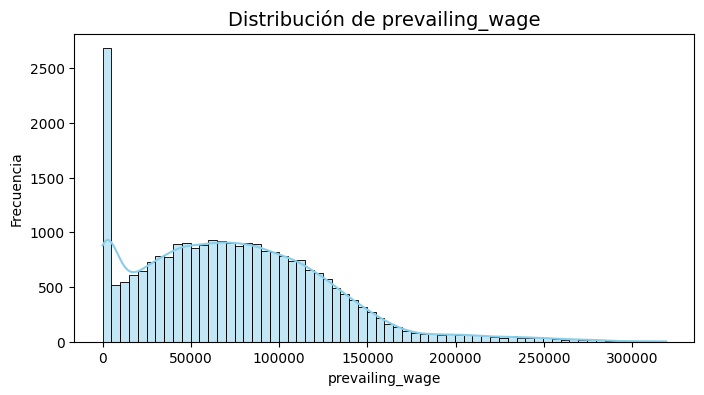

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = ['no_of_employees', 'company_age', 'prevailing_wage']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True, color='skyblue')
    plt.title(f'Distribución de {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()



In [110]:
X[columnas_numericas].skew(axis=0, skipna=True)

no_of_employees    12.265260
company_age         2.037301
prevailing_wage     0.755776
dtype: float64

In [111]:
from sklearn.preprocessing import PowerTransformer

# Instanciar el transformador (Yeo-Johnson es el recomendado si hay ceros)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Ajustar y transformar las columnas numéricas
X_copy = pt.fit_transform(
    df[['prevailing_wage', 'no_of_employees']]
)


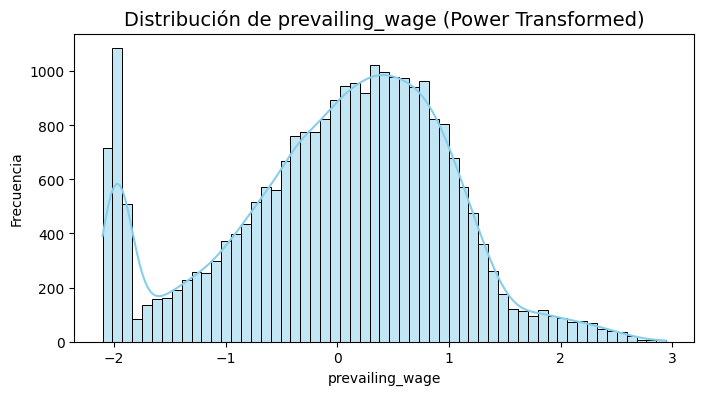

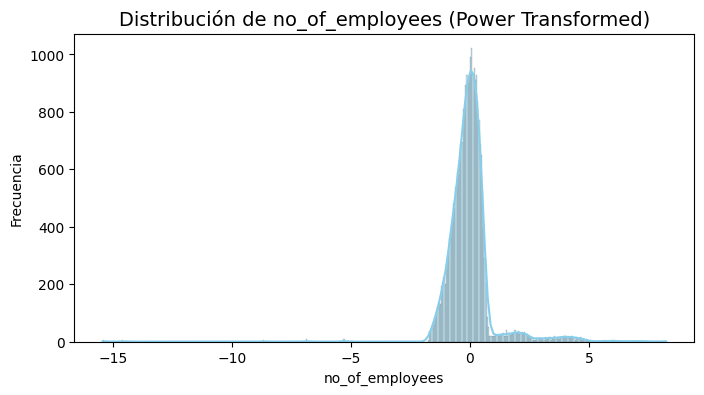

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

# 1. Definir exactamente las columnas a transformar
columnas_a_transformar = ['prevailing_wage', 'no_of_employees']

# 2. Instanciar y transformar
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_copy = pt.fit_transform(df[columnas_a_transformar])

# 3. Convertir a DataFrame usando la MISMA lista de columnas
X_copy = pd.DataFrame(X_copy, columns=columnas_a_transformar)

# 4. Graficar el resultado
for col in columnas_a_transformar:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=X_copy[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col} (Power Transformed)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()


In [113]:
df.columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'region_of_employment',
       'prevailing_wage', 'unit_of_wage', 'full_time_position', 'case_status',
       'company_age'],
      dtype='object')

In [114]:
num_feature = list(X.select_dtypes(exclude= 'object').columns)
num_feature

['no_of_employees', 'prevailing_wage', 'company_age']

In [117]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

or_columns = [
    'education_of_employee', 'has_job_experience',
    'requires_job_training', 'full_time_position'
]
oh_columns = ['continent', 'unit_of_wage', 'region_of_employment']
transfor_columns = ['no_of_employees', 'company_age']

# ✅ Instanciar agregando los paréntesis ()
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
ordinal_encoder = OrdinalEncoder()

transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])

preprocessor = ColumnTransformer([
    ('OneHotEncoder', oh_transformer, oh_columns),
    ('OrdinalEncoder', ordinal_encoder, or_columns),
    ('Transformer', transform_pipe, transfor_columns), 
    ('StandardScaler', numeric_transformer, num_feature)
])

# Ahora esta celda funcionará perfectamente:
X = preprocessor.fit_transform(X)


In [118]:
X

array([[ 0.        ,  1.        ,  0.        , ...,  0.38666657,
        -1.39853722, -0.65122993],
       [ 0.        ,  1.        ,  0.        , ..., -0.14228155,
         0.1698353 , -0.53321103],
       [ 0.        ,  1.        ,  0.        , ...,  1.69498375,
         0.91907852, -0.6748337 ],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.19871259,
         1.36027953,  1.63833662],
       [ 0.        ,  1.        ,  0.        , ..., -0.16387483,
         0.22150859,  2.18122353],
       [ 0.        ,  1.        ,  0.        , ..., -0.10805575,
        -0.06776315,  0.45814768]], shape=(25480, 24))

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# Algoritmos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. Separar datos en Train y Test (manteniendo la proporción de clases con stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Diccionario de modelos a evaluar
# Nota: Incluimos class_weight='balanced' o scale_pos_weight para el desbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # Para XGBoost si la clase minoritaria es 1

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
}

# 3. Función para evaluar métricas de un modelo
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Entrenar
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    # Calcular Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "ROC-AUC": roc_auc}

# 4. Iterar y recopilar resultados
results = []
for name, model in models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

# 5. Crear Tabla Comparativa ordenada por F1-Score (o ROC-AUC)
df_results = pd.DataFrame(results)[["Model", "F1-Score", "ROC-AUC", "Accuracy", "Precision", "Recall"]]
df_results = df_results.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("=== COMPARATIVA DE MODELOS ===")
display(df_results)


=== COMPARATIVA DE MODELOS ===


,Model,F1-Score,ROC-AUC,Accuracy,Precision,Recall
0,LightGBM,0.607913,0.776156,0.718014,0.564622,0.658392
1,XGBoost,0.593699,0.759748,0.706436,0.549246,0.645981
2,Gradient Boosting,0.567408,0.775562,0.740581,0.635630,0.512411
3,Logistic Regression,0.527778,0.686594,0.646389,0.474105,0.595154
4,AdaBoost,0.508073,0.763545,0.730965,0.646575,0.418440
5,Random Forest,0.503739,0.745399,0.713501,0.592800,0.437943
6,Decision Tree,0.474153,0.607143,0.652669,0.476703,0.471631


In [122]:
best_model_name = df_results.iloc[0]["Model"]
best_f1 = df_results.iloc[0]["F1-Score"]

print(f"El mejor modelo es: {best_model_name} con un F1-Score de: {best_f1:.4f}")


El mejor modelo es: LightGBM con un F1-Score de: 0.6079


In [123]:
# 1. Definir los parámetros según el mejor modelo
if best_model_name == "XGBoost":
    base_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
elif best_model_name == "Random Forest":
    base_model = RandomForestClassifier(class_weight='balanced', random_state=42)
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
else:
    # Caso general: Regresión Logística
    base_model = LogisticRegression(class_weight='balanced', random_state=42)
    param_grid = {
        'C': [0.01, 0.1, 1.0, 10.0],
        'solver': ['liblinear', 'lbfgs']
    }

# 2. Configurar Stratified K-Fold (5 Folds)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Configurar GridSearchCV buscando maximizar F1-Score
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 4. Ejecutar el Fine Tuning en los datos de Entrenamiento
print(f"Iniciando Fine Tuning para {best_model_name}...")
grid_search.fit(X_train, y_train)

# 5. Obtener el Mejor Modelo y sus Parámetros
best_tuned_model = grid_search.best_estimator_
print("\nMejores Hiperparámetros Encontrados:")
print(grid_search.best_params_)
print(f"Mejor F1-Score en CV: {grid_search.best_score_:.4f}")


Iniciando Fine Tuning para LightGBM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores Hiperparámetros Encontrados:
{'C': 1.0, 'solver': 'lbfgs'}
Mejor F1-Score en CV: 0.5216



=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST SET) ===
Accuracy:  0.6464
Precision: 0.4741
Recall:    0.5952
F1-Score:  0.5278
ROC-AUC:   0.6866


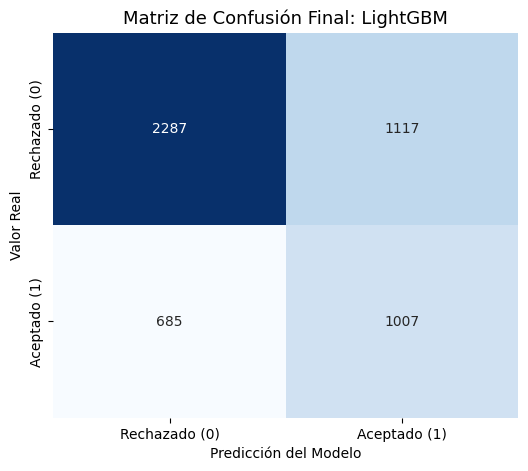

In [124]:
# Predicciones finales
y_pred_final = best_tuned_model.predict(X_test)
y_proba_final = best_tuned_model.predict_proba(X_test)[:, 1]

# Métricas finales
print("\n=== EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST SET) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_final):.4f}")

# Visualizar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Rechazado (0)', 'Aceptado (1)'],
            yticklabels=['Rechazado (0)', 'Aceptado (1)'])
plt.title(f'Matriz de Confusión Final: {best_model_name}', fontsize=13)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()
